<a href="https://colab.research.google.com/github/donlasSR/nlp/blob/main/Whisper_Finetuning_Full_LoRA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install -q datasets transformers evaluate huggingface_hub jiwer pythainlp

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 484.9/484.9 kB 9.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.0/84.0 kB 7.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17.9/17.9 MB 85.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 116.3/116.3 kB 9.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 143.5/143.5 kB 11.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 90.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 194.8/194.8 kB 16.7 MB/s eta 0:00:00


In [ ]:
!pip install -q -U "huggingface_hub[cli]"

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 67.7/67.7 kB 1.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 468.0/468.0 kB 9.5 MB/s eta 0:00:00


In [ ]:
import gc
import os
import evaluate
import numpy as np
import pandas as pd
import torch
import librosa
from typing import List
from torch.utils.data import Dataset
from datasets import load_dataset, Audio
from transformers import (
    WhisperFeatureExtractor,
    WhisperTokenizer,
    WhisperProcessor,
    WhisperForConditionalGeneration,
    Seq2SeqTrainingArguments,
    Seq2SeqTrainer
)
from peft import (
    LoraConfig,
    get_peft_model,
    PeftModel,
    PeftConfig
)
from tqdm.notebook import tqdm
from pythainlp.tokenize import word_tokenize
from huggingface_hub import login
from dataclasses import dataclass
import matplotlib.pyplot as plt

In [ ]:
os.environ["WANDB_MODE"] = "offline"

In [ ]:
device = "cuda" if torch.cuda.is_available() else "cpu"
torch_dtype = torch.float16 if device=="cuda" else torch.float32
device, torch_dtype

('cuda', torch.float16)

# **Kaggle Dataset**

In [ ]:
!mkdir ~/.kaggle
!cp /content/kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

In [ ]:
!kaggle competitions download -c hcu-speech-recognition-challenge-2025

 93% 35.0M/37.7M [00:00<00:00, 170MB/s] 
100% 37.7M/37.7M [00:00<00:00, 155MB/s]


In [ ]:
!unzip -q /content/hcu-speech-recognition-challenge-2025.zip

# **Load Model**

In [ ]:
lang = "th"
task = "transcribe"
model_name = "openai/whisper-small"

# **Load Model with LoRA**

In [ ]:
model = WhisperForConditionalGeneration.from_pretrained(model_name)
model.generation_config.language = lang
model.generation_config.task = task
model.generation_config.forced_decoder_ids = None

/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/2.32k [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/1.53G [00:00<?, ?B/s]

generation_config.json:   0%|          | 0.00/3.65k [00:00<?, ?B/s]

In [ ]:
model = WhisperForConditionalGeneration.from_pretrained(model_name, torch_dtype=torch_dtype)
model.generation_config.language = lang
model.generation_config.task = task
model.generation_config.forced_decoder_ids = None

model.config.apply_spec_augment = True
model.config.mask_time_prob = 0.3
model.config.mask_feature_prob = 0.2

model.enable_input_require_grads()

# LoRA
config = LoraConfig(
    r=8,
    lora_alpha=32,
    target_modules=["k_proj", "q_proj", "v_proj"],
    lora_dropout=0.1,
    # task_type="SEQ_2_SEQ_LM"
)
model = get_peft_model(model, config)
model.print_trainable_parameters()

trainable params: 221,184 || all params: 37,981,824 || trainable%: 0.5823


# **Clean Dataset**

In [ ]:
for phase in ["train", "dev"]:

    drop_list = []

    df = pd.read_csv(f"/content/{phase}.csv")

    for i in range(len(df)):
        audio_path = os.path.join(f"/content/{phase}", df.audio[i])
        if not os.path.exists(audio_path):
            print(df.audio[i])
            drop_list.append(df.audio[i])

    df = df[~df.audio.isin(drop_list)].reset_index(drop=True)
    df.to_csv(f"/content/{phase}.csv", index=False)

650020_AUG_1088.mp3


# **Custom Dataset**

In [ ]:
class CustomDataset(Dataset):
    def __init__(self,
        ann_file_path: str,
        audio_folder_path: str,
        target_sr: int = 16000,
        feature_extractor: WhisperFeatureExtractor = None,
        tokenizer: WhisperTokenizer = None
    ):
        super(CustomDataset, self).__init__()
        self.audio_folder_path = audio_folder_path
        self.target_sr = target_sr
        self.ann_file = pd.read_csv(ann_file_path)
        self.ann_file["audio"] = self.ann_file.audio.apply(
            lambda x: os.path.join(audio_folder_path, x)
        )

        self.tokenizer = tokenizer
        self.feature_extractor = feature_extractor

    def __len__(self):
        return self.ann_file.shape[0]

    def __getitem__(self, idx):
        audio_path, sentence = self.ann_file.iloc[idx]

        array, sr = librosa.load(path=audio_path, sr=self.target_sr)
        input_features = self.feature_extractor(
            array, sampling_rate=sr
        ).input_features[0]

        labels = self.tokenizer(sentence, truncation=True, max_length=448).input_ids

        return dict(
            waveform=array,
            input_features=input_features,
            sentence=sentence,
            labels=labels
        )

In [ ]:
feature_extractor = WhisperFeatureExtractor.from_pretrained(model_name)
tokenizer = WhisperTokenizer.from_pretrained(model_name)
tokenizer.set_prefix_tokens(language=lang, task=task)

datasets = {
    phase: CustomDataset(
        ann_file_path=f"/content/{phase}.csv",
        audio_folder_path=f"/content/{phase}",
        target_sr=16_000,
        feature_extractor=feature_extractor,
        tokenizer=tokenizer
    ) for phase in ["train", "dev"]
}

preprocessor_config.json:   0%|          | 0.00/339 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/283k [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/1.04M [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/494k [00:00<?, ?B/s]

normalizer.json:   0%|          | 0.00/52.7k [00:00<?, ?B/s]

added_tokens.json:   0%|          | 0.00/34.6k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/2.19k [00:00<?, ?B/s]

In [ ]:
sample = datasets["train"][0]

In [ ]:
print(f"sentence: {sample['sentence']}")
print(f"input_ids: {sample['labels']}")
print(f"decode: {tokenizer.decode(sample['labels'])}")

sentence: สาขาวิชากายภาพบำบัดเป็นวิชาชีพที่ต้องปฏิบัติโดยตรงต่อมนุษย์ทุกวัย ทั้งในคนที่มีปัญหาสุขภาพจากภาวะโรค การบาดเจ็บ ภาวะเสื่อม และคนปกติ
input_ids: [50258, 50289, 50359, 50363, 13715, 4943, 20512, 4943, 7643, 9596, 17080, 32550, 23398, 839, 254, 4943, 17297, 10196, 24865, 10196, 5981, 9345, 23379, 12055, 4131, 7643, 9596, 17080, 4943, 17080, 6033, 17297, 11099, 12774, 11526, 4750, 18970, 17071, 839, 237, 9596, 10196, 5981, 11526, 9596, 24929, 9345, 7044, 11526, 7067, 7212, 11526, 4294, 5104, 6192, 4131, 15417, 839, 102, 7044, 23948, 11099, 15417, 6223, 7643, 5981, 7044, 220, 11099, 27216, 7212, 15412, 4131, 41404, 11099, 12774, 6192, 6033, 17071, 5981, 49541, 10982, 4943, 13715, 15417, 20512, 839, 254, 4943, 17297, 14190, 32550, 839, 254, 4943, 7643, 8055, 24929, 7067, 8163, 44579, 37230, 10196, 4943, 9345, 5914, 230, 12055, 10196, 220, 839, 254, 4943, 7643, 8055, 48556, 30121, 5104, 6192, 220, 22214, 8055, 41404, 17071, 6223, 11526, 9596, 50257]
decode: <|startoftranscript|><|th

It is strongly recommended to pass the `sampling_rate` argument to this function. Failing to do so can result in silent errors that might be hard to debug.


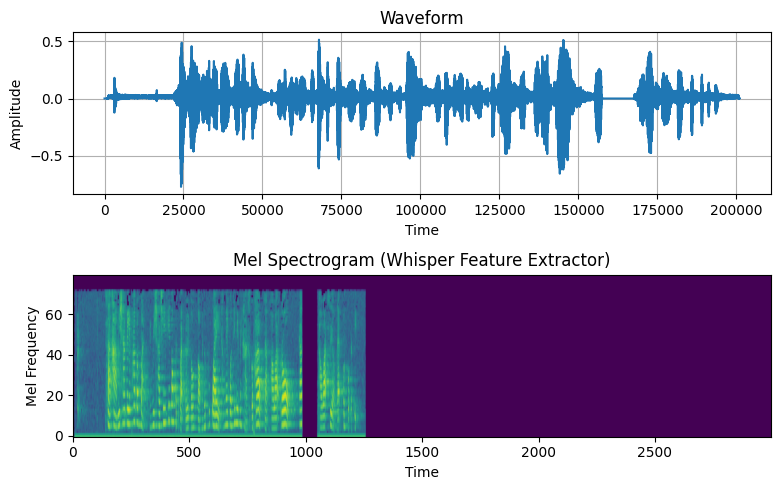

In [ ]:
# Extract input features (Mel spectrogram)
input_features = feature_extractor(sample["waveform"], return_tensors="pt").input_features
mel_spectrogram = input_features[0]

# Plot the waveform and the corresponding Mel spectrogram
fig, axs = plt.subplots(2, 1, figsize=(8, 5))

axs[0].plot(sample["waveform"])
axs[0].set_title("Waveform")
axs[0].set_xlabel("Time")
axs[0].set_ylabel("Amplitude")
axs[0].grid()

axs[1].imshow(mel_spectrogram, aspect='auto', origin='lower')
axs[1].set_title("Mel Spectrogram (Whisper Feature Extractor)")
axs[1].set_xlabel("Time")
axs[1].set_ylabel("Mel Frequency")

plt.tight_layout()
plt.show()

# **Data Collator**

In [ ]:
@dataclass
class DataCollatorSpeechSeq2SeqWithPadding:

    def __init__(self, processor, decoder_start_token_id):
        self.processor = processor
        self.decoder_start_token_id = decoder_start_token_id

    def __call__(self, features):

        # Prepare input features by padding and converting to tensor
        input_features = [{"input_features": feature["input_features"]} for feature in features]
        batch = self.processor.feature_extractor.pad(input_features, return_tensors="pt")

        # Prepare labels by padding and converting to tensor
        label_features = [{"input_ids": feature["labels"]} for feature in features]
        labels_batch = self.processor.tokenizer.pad(label_features, return_tensors="pt")

        # Mask padding tokens in labels
        labels = labels_batch["input_ids"].masked_fill(labels_batch.attention_mask.ne(1), -100)

        # Remove the decoder start token
        if (labels[:, 0] == self.decoder_start_token_id).all().cpu().item():
            labels = labels[:, 1:]

        batch["labels"] = labels
        return batch

In [ ]:
processor = WhisperProcessor.from_pretrained(model_name, language=lang, task=task)

data_collator = DataCollatorSpeechSeq2SeqWithPadding(
    processor=processor,
    decoder_start_token_id=model.config.decoder_start_token_id,
)

# **Evaluation Metrics**

In [ ]:
metric = evaluate.load("cer")

def compute_metrics(pred):
    pred_ids = pred.predictions
    label_ids = pred.label_ids

    label_ids[label_ids == -100] = tokenizer.pad_token_id

    pred_str = tokenizer.batch_decode(pred_ids, skip_special_tokens=True)
    label_str = tokenizer.batch_decode(label_ids, skip_special_tokens=True)

    cer = 100 * metric.compute(predictions=pred_str, references=label_str)

    return {"cer": cer}

# **Training**

In [ ]:
training_args = Seq2SeqTrainingArguments(
    output_dir="./model_output",
    per_device_train_batch_size=8,
    gradient_accumulation_steps=1,
    num_train_epochs=5.0,
    learning_rate=5e-5,
    gradient_checkpointing=True,
    fp16=True,
    bf16=False,
    optim="adamw_torch_fused", # adamw_torch_fused, adamw_8bit, adamw_torch, sgd
    eval_strategy="epoch",
    per_device_eval_batch_size=8,
    predict_with_generate=True,
    generation_max_length=256,
    save_strategy="epoch",
    save_total_limit=5,
    logging_steps=50,
    report_to=None,
    push_to_hub=False,
)

In [ ]:
trainer = Seq2SeqTrainer(
    args=training_args,
    model=model,
    train_dataset=datasets["train"],
    eval_dataset=datasets["dev"],
    data_collator=data_collator,
    compute_metrics=compute_metrics,
    tokenizer=processor.feature_extractor
)

<ipython-input-21-44c4daf9189f>:1: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Seq2SeqTrainer.__init__`. Use `processing_class` instead.
  trainer = Seq2SeqTrainer(


In [ ]:
trainer.train()
model.save_pretrained(training_args.output_dir)
processor.save_pretrained(training_args.output_dir)

wandb: WARNING The `run_name` is currently set to the same value as `TrainingArguments.output_dir`. If this was not intended, please specify a different run name by setting the `TrainingArguments.run_name` parameter.
wandb: Using wandb-core as the SDK backend.  Please refer to https://wandb.me/wandb-core for more information.


Passing a tuple of `past_key_values` is deprecated and will be removed in Transformers v4.43.0. You should pass an instance of `EncoderDecoderCache` instead, e.g. `past_key_values=EncoderDecoderCache.from_legacy_cache(past_key_values)`.
`use_cache = True` is incompatible with gradient checkpointing. Setting `use_cache = False`...


Epoch,Training Loss,Validation Loss,Cer
1,0.224500,0.359232,12.618274
2,0.089000,0.317586,10.139811
3,0.037700,0.344971,11.319023
4,0.010100,0.356370,8.353340
5,0.001500,0.348078,7.640164


You have passed task=transcribe, but also have set `forced_decoder_ids` to [[1, 50259], [2, 50359], [3, 50363]] which creates a conflict. `forced_decoder_ids` will be ignored in favor of task=transcribe.
The attention mask is not set and cannot be inferred from input because pad token is same as eos token. As a consequence, you may observe unexpected behavior. Please pass your input's `attention_mask` to obtain reliable results.
/usr/local/lib/python3.11/dist-packages/transformers/modeling_utils.py:2758: UserWarning: Moving the following attributes in the config to the generation config: {'max_length': 448, 'suppress_tokens': [1, 2, 7, 8, 9, 10, 14, 25, 26, 27, 28, 29, 31, 58, 59, 60, 61, 62, 63, 90, 91, 92, 93, 359, 503, 522, 542, 873, 893, 902, 918, 922, 931, 1350, 1853, 1982, 2460, 2627, 3246, 3253, 3268, 3536, 3846, 3961, 4183, 4667, 6585, 6647, 7273, 9061, 9383, 10428, 10929, 11938, 12033, 12331, 12562, 13793, 14157, 14635, 15265, 15618, 16553, 16604, 18362, 18956, 20075, 21675, 2

[]

In [ ]:
del model
gc.collect()
torch.cuda.empty_cache()

In [ ]:
# Load peft model
peft_model_id = "adapter_checkpoint_path"
peft_config = PeftConfig.from_pretrained(peft_model_id)

model = WhisperForConditionalGeneration.from_pretrained(
    peft_config.base_model_name_or_path,
    torch_dtype=torch.bfloat16
)
model = PeftModel.from_pretrained(model, peft_model_id)

# Merge model with adapter
model = model.merge_and_unload()
model.save_pretrained(training_args.output_dir, max_shard_size="10GB")

# **Inference**

In [ ]:
test_folder_path = "/content/test"
df_test = pd.read_csv("/content/test.csv")

In [ ]:
# Read audio function
def read_audio_to_array(
    audio_path: str,
    target_sr: int,
) -> np.ndarray:

    # load audio
    array, sr = librosa.load(path=audio_path, sr=target_sr)

    return array

# Batch transcribe function
def batch_transcribe(
    model,
    processor,
    audio_path_list: str,
    batch_size: int,
    sampling_rate: int,
    torch_dtype: torch.dtype,
    device: str
) -> List[str]:

    model.eval()
    transcriptions = []

    # Process audio files in batches
    for i in tqdm(range(0, len(audio_path_list), batch_size)):
        audio_batch = audio_path_list[i : i + batch_size]

        # Read and preprocess audio files
        array_list = [
            read_audio_to_array(audio_path, sampling_rate)
                for audio_path in audio_batch
        ]

        # Process audio arrays into input features
        input_features = processor(
            array_list,
            sampling_rate=sampling_rate,
            return_tensors="pt"
        ).input_features
        input_features = input_features.to(torch_dtype)

        # Generate transcriptions
        with torch.no_grad():
            output_ids = model.generate(
                input_features.to(device),
                max_new_tokens=20,
                temperature=0.4
            )
            output_texts = processor.batch_decode(output_ids, skip_special_tokens=True)

        transcriptions.extend(output_texts)

    return transcriptions

In [ ]:
lang = "th"
task = "transcribe"
torch_dtype = torch.float16
model_path ="/content/model_output"

In [ ]:
# Load model & Processor
processor = WhisperProcessor.from_pretrained(model_path, lang=lang, task=task)
model = WhisperForConditionalGeneration.from_pretrained(model_path, torch_dtype=torch_dtype)
model.generation_config.forced_decoder_ids = processor.get_decoder_prompt_ids(language=lang, task=task)
model = model.to(device)

In [ ]:
audio_path_list = df_test.audio.apply(
    lambda x: os.path.join(test_folder_path, x)
).to_list()

transcriptions = batch_transcribe(
    model=model,
    processor=processor,
    audio_path_list=audio_path_list,
    batch_size=16,
    sampling_rate=16_000,
    torch_dtype=torch_dtype,
    device=device
)

df_test["sentence"] = transcriptions
df_test["sentence"] = df_test.sentence.apply(
    lambda t: " ".join(word_tokenize(t.lower().replace(" ", ""), engine="newmm"))
)

  0%|          | 0/13 [00:00<?, ?it/s]

You have passed task=transcribe, but also have set `forced_decoder_ids` to [(1, 50289), (2, 50359), (3, 50363)] which creates a conflict. `forced_decoder_ids` will be ignored in favor of task=transcribe.


In [ ]:
df_test

,audio,sentence
0,TE_0001.mp3,คณะ ศาสตร์ พัฒน สุข เน้น การพัฒนา ผู้ป่วย และ ...
1,TE_0002.mp3,มหาวิทยาลัย หัวเฉียว มี หลักสูตร หน้า ต่อย ที่...
2,TE_0003.mp3,การ จัดการ สุขภาพ ชุมชน เป็น สิ่ง สำคัญ เพื่อ ...
3,TE_0004.mp3,คณะ สาธารณสุข จาก กิจกรรม ส่งเสริม สุขภาพ อย่า...
4,TE_0005.mp3,การวิจัย และ นวัตกรรม เป็น ห วัติ สำคัญ ของ กา...
...,...,...
195,TE_0196.mp3,ค่า เทอม ของ คณะ สาธารณสุข ประมาณ เท่าใด เหรอ ...
196,TE_0197.mp3,ถ้า สนใจ อยาก เรียน สาธารณสุข ต้อง ติดต่อ ที่ไ...
197,TE_0198.mp3,ที่ คณะ สาธารณสุข มี ทุนการศึกษา ให้ ไหม อยากไ...
198,TE_0199.mp3,จบ จาก คณะ สาธารณสุข แล้ว ทำงาน อาจ ได้ บ้าง ม...


In [ ]:
df_test.to_csv("submission.csv", index=False)